# Traffic Congestion Prediction

This notebook develops a complete machine learning pipeline for traffic prediction using the `traffic.csv` dataset.

The objective is to predict the number of vehicles for a given junction and time, then convert this numerical prediction into a congestion level:

- **0–50 vehicles**: Fluid
- **51–150 vehicles**: Moderate
- **>150 vehicles**: Congested

In [45]:
# ============================================================
# 1. Setup, imports and global configuration
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("traffic.csv")

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

This first cell imports the libraries used in the notebook and defines global parameters such as the random seed and the dataset path.

The notebook expects `traffic.csv` to be located in the same folder as the notebook.

In [46]:
# ============================================================
# 2. Data loading
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (48120, 4)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


None

The dataset contains hourly traffic observations. The main target variable is `Vehicles`, which represents the number of vehicles observed for a specific junction and timestamp.

In [47]:
# ============================================================
# 3. Basic data inspection
# ============================================================

display(df.describe(include="all"))
print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicated rows:", df.duplicated().sum())
print("\nNumber of junctions:", df["Junction"].nunique())
print("Junction values:", sorted(df["Junction"].unique()))

,DateTime,Junction,Vehicles,ID
count,48120,48120.000000,48120.000000,4.812000e+04
unique,14592,NaN,NaN,NaN
top,2017-01-01 00:00:00,NaN,NaN,NaN
freq,4,NaN,NaN,NaN
mean,NaN,2.180549,22.791334,2.016330e+10
std,NaN,0.966955,20.750063,5.944854e+06
min,NaN,1.000000,1.000000,2.015110e+10
25%,NaN,1.000000,9.000000,2.016042e+10
50%,NaN,2.000000,15.000000,2.016093e+10
75%,NaN,3.000000,29.000000,2.017023e+10



Missing values:


DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


Duplicated rows: 0

Number of junctions: 4
Junction values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


This step checks the structure of the dataset, missing values, duplicated rows, and the number of junctions.

This is important because the quality of the dataset directly impacts the reliability of the prediction models.

In [48]:
# ============================================================
# 4. Date conversion and chronological sorting
# ============================================================

df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["Junction", "DateTime"]).reset_index(drop=True)

print("Start date:", df["DateTime"].min())
print("End date:", df["DateTime"].max())
display(df.head())

Start date: 2015-11-01 00:00:00
End date: 2017-06-30 23:00:00


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


The `DateTime` column is converted into a proper datetime format. The dataset is then sorted by `Junction` and `DateTime`.

This is especially important for time-dependent features such as lag features and rolling averages.

## Exploratory Data Analysis

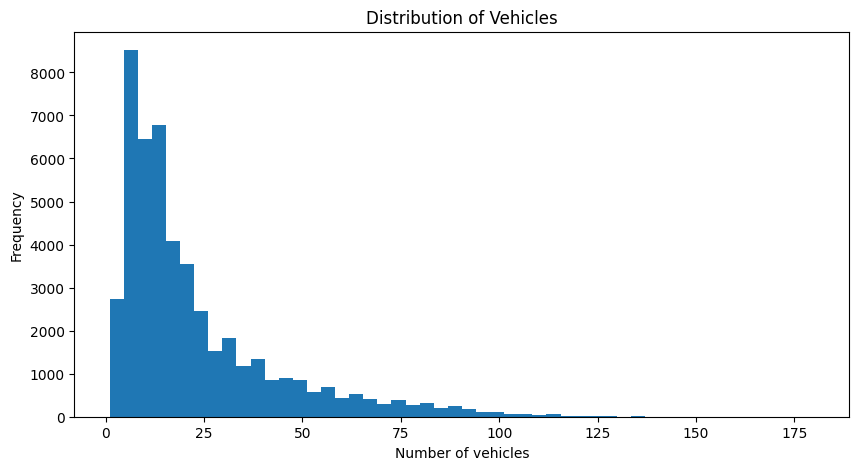

In [49]:
# ============================================================
# 5. Distribution of the target variable
# ============================================================

plt.figure()
plt.hist(df["Vehicles"], bins=50)
plt.title("Distribution of Vehicles")
plt.xlabel("Number of vehicles")
plt.ylabel("Frequency")
plt.show()

This visualization shows the distribution of the number of vehicles.

It helps us understand whether the target variable is balanced or skewed, and whether there are extreme values.

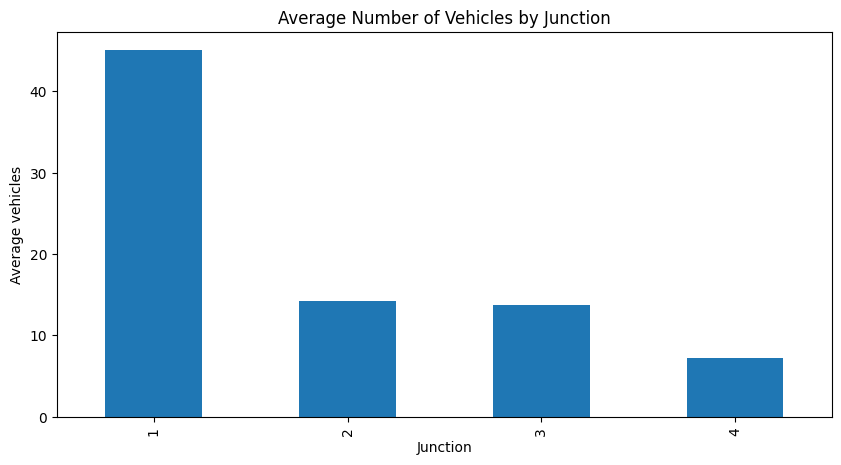

,Average Vehicles
Junction,
1,45.052906
2,14.253221
3,13.694010
4,7.251611


In [50]:
# ============================================================
# 6. Average traffic by junction
# ============================================================

traffic_by_junction = df.groupby("Junction")["Vehicles"].mean().sort_index()

plt.figure()
traffic_by_junction.plot(kind="bar")
plt.title("Average Number of Vehicles by Junction")
plt.xlabel("Junction")
plt.ylabel("Average vehicles")
plt.show()

display(traffic_by_junction.to_frame("Average Vehicles"))

This plot compares the average traffic level across the four junctions.

The junction is an important feature because different junctions can have very different traffic patterns.

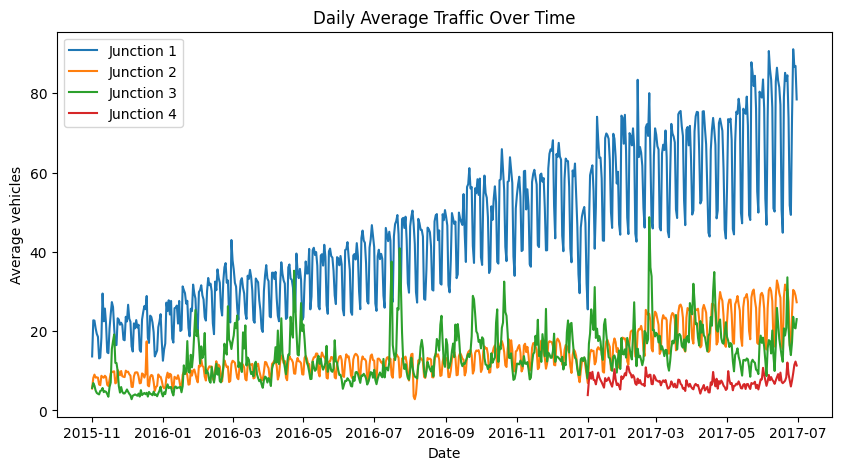

In [51]:
# ============================================================
# 7. Traffic evolution over time by junction
# ============================================================

daily_traffic = (
    df.set_index("DateTime")
      .groupby("Junction")["Vehicles"]
      .resample("D")
      .mean()
      .reset_index()
)

plt.figure()
for junction in sorted(daily_traffic["Junction"].unique()):
    subset = daily_traffic[daily_traffic["Junction"] == junction]
    plt.plot(subset["DateTime"], subset["Vehicles"], label=f"Junction {junction}")

plt.title("Daily Average Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Average vehicles")
plt.legend()
plt.show()

The original dataset is hourly, so the traffic is aggregated by day to make the temporal trend easier to read.

This graph helps identify long-term trends, seasonality, and differences between junctions.

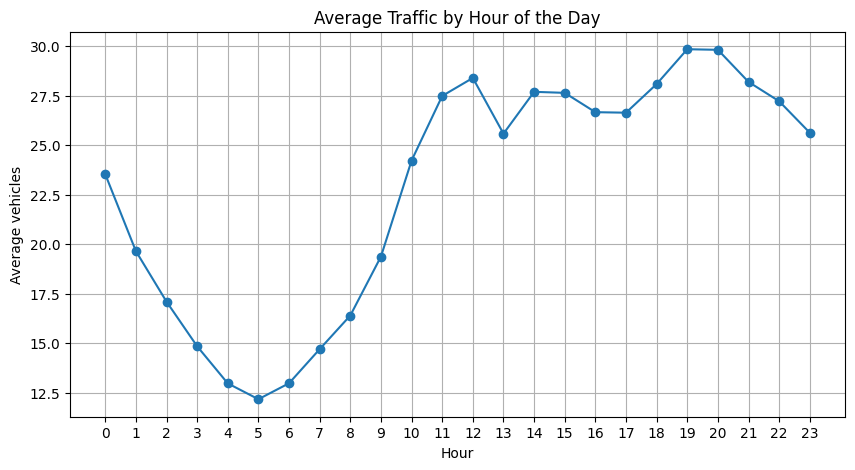

In [52]:
# ============================================================
# 8. Average traffic by hour
# ============================================================

df["hour_temp"] = df["DateTime"].dt.hour

hourly_traffic = df.groupby("hour_temp")["Vehicles"].mean()

plt.figure()
hourly_traffic.plot(kind="line", marker="o")
plt.title("Average Traffic by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Average vehicles")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

df = df.drop(columns=["hour_temp"])

Traffic usually depends strongly on the hour of the day.

For example, morning and evening peak hours can be associated with commuting patterns. This motivates the creation of time-based features.

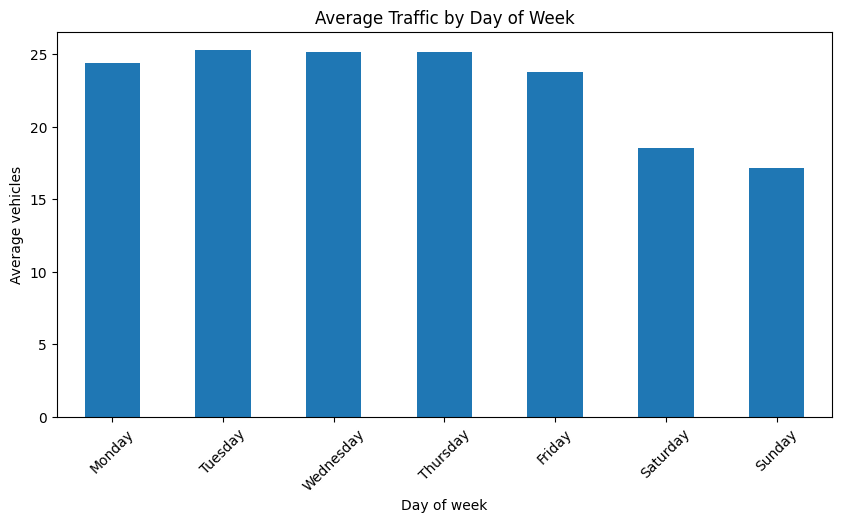

In [53]:
# ============================================================
# 9. Average traffic by day of week
# ============================================================

df["day_of_week_temp"] = df["DateTime"].dt.dayofweek
weekday_traffic = df.groupby("day_of_week_temp")["Vehicles"].mean()

weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure()
weekday_traffic.plot(kind="bar")
plt.title("Average Traffic by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Average vehicles")
plt.xticks(ticks=range(7), labels=weekday_labels, rotation=45)
plt.show()

df = df.drop(columns=["day_of_week_temp"])

This visualization shows whether traffic differs between weekdays and weekends.

This is useful because traffic demand is often related to workdays, school days, and weekend activities.

## Feature Engineering

### Feature 1 — Hour of the day

We extract the hour from the timestamp.

This is useful because traffic patterns are strongly linked to daily routines such as commuting in the morning and evening.

In [54]:
# ============================================================
# 10. Feature engineering: hour
# ============================================================

df["hour"] = df["DateTime"].dt.hour
display(df[["DateTime", "hour"]].head())

,DateTime,hour
0,2015-11-01 00:00:00,0
1,2015-11-01 01:00:00,1
2,2015-11-01 02:00:00,2
3,2015-11-01 03:00:00,3
4,2015-11-01 04:00:00,4


### Feature 2 — Day of the week

We extract the day of the week as a number from 0 to 6:

- 0 = Monday
- 6 = Sunday

This allows the model to distinguish between weekdays and weekends.

In [55]:
# ============================================================
# 11. Feature engineering: day of week
# ============================================================

df["day_of_week"] = df["DateTime"].dt.dayofweek
df["weekday_name"] = df["DateTime"].dt.day_name()

display(df[["DateTime", "day_of_week", "weekday_name"]].head())

,DateTime,day_of_week,weekday_name
0,2015-11-01 00:00:00,6,Sunday
1,2015-11-01 01:00:00,6,Sunday
2,2015-11-01 02:00:00,6,Sunday
3,2015-11-01 03:00:00,6,Sunday
4,2015-11-01 04:00:00,6,Sunday


### Feature 3 — Weekend indicator

We create a binary variable:

- `1` if the observation is on Saturday or Sunday
- `0` otherwise

This is useful because weekend traffic can be different from weekday traffic.

In [56]:
# ============================================================
# 12. Feature engineering: weekend indicator
# ============================================================

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

display(df[["DateTime", "weekday_name", "is_weekend"]].head())

,DateTime,weekday_name,is_weekend
0,2015-11-01 00:00:00,Sunday,1
1,2015-11-01 01:00:00,Sunday,1
2,2015-11-01 02:00:00,Sunday,1
3,2015-11-01 03:00:00,Sunday,1
4,2015-11-01 04:00:00,Sunday,1


### Feature 4 — Month and year

We extract the month and the year.

The month can help capture seasonal effects, while the year can capture long-term evolution in traffic volume.

In [57]:
# ============================================================
# 13. Feature engineering: month and year
# ============================================================

df["month"] = df["DateTime"].dt.month
df["year"] = df["DateTime"].dt.year

display(df[["DateTime", "month", "year"]].head())

,DateTime,month,year
0,2015-11-01 00:00:00,11,2015
1,2015-11-01 01:00:00,11,2015
2,2015-11-01 02:00:00,11,2015
3,2015-11-01 03:00:00,11,2015
4,2015-11-01 04:00:00,11,2015


### Feature 5 — Time period of the day

We create a more interpretable feature that groups hours into meaningful periods:

- Night
- Morning peak
- Day
- Evening peak

This feature can help the model capture high-level traffic patterns.

In [58]:
# ============================================================
# 14. Feature engineering: period of the day
# ============================================================

def get_period(hour):
    if 6 <= hour < 10:
        return "morning_peak"
    if 10 <= hour < 16:
        return "day"
    if 16 <= hour < 20:
        return "evening_peak"
    return "night"


df["period"] = df["hour"].apply(get_period)

display(df[["DateTime", "hour", "period"]].head(12))

,DateTime,hour,period
0,2015-11-01 00:00:00,0,night
1,2015-11-01 01:00:00,1,night
2,2015-11-01 02:00:00,2,night
3,2015-11-01 03:00:00,3,night
4,2015-11-01 04:00:00,4,night
5,2015-11-01 05:00:00,5,night
6,2015-11-01 06:00:00,6,morning_peak
7,2015-11-01 07:00:00,7,morning_peak
8,2015-11-01 08:00:00,8,morning_peak
9,2015-11-01 09:00:00,9,morning_peak


### Feature 6 — Lag features

We create lag features using the previous traffic values for each junction:

- `lag_1`: traffic one hour before
- `lag_24`: traffic at the same hour the previous day

These features are very important for time series forecasting because the recent past is often a strong predictor of the near future.

In [59]:
# ============================================================
# 15. Feature engineering: lag features
# ============================================================

df["lag_1"] = df.groupby("Junction")["Vehicles"].shift(1)
df["lag_24"] = df.groupby("Junction")["Vehicles"].shift(24)

display(df[["DateTime", "Junction", "Vehicles", "lag_1", "lag_24"]].head(30))

,DateTime,Junction,Vehicles,lag_1,lag_24
0,2015-11-01 00:00:00,1,15,NaN,NaN
1,2015-11-01 01:00:00,1,13,15.0,NaN
2,2015-11-01 02:00:00,1,10,13.0,NaN
3,2015-11-01 03:00:00,1,7,10.0,NaN
4,2015-11-01 04:00:00,1,9,7.0,NaN
5,2015-11-01 05:00:00,1,6,9.0,NaN
6,2015-11-01 06:00:00,1,9,6.0,NaN
7,2015-11-01 07:00:00,1,8,9.0,NaN
8,2015-11-01 08:00:00,1,11,8.0,NaN
9,2015-11-01 09:00:00,1,12,11.0,NaN


### Feature 7 — Rolling averages

We create rolling averages based only on past values:

- `rolling_mean_3`: average traffic over the previous 3 hours
- `rolling_mean_24`: average traffic over the previous 24 hours

The `.shift(1)` ensures that the current target value is not used to predict itself.

In [60]:
# ============================================================
# 16. Feature engineering: rolling averages
# ============================================================

df["rolling_mean_3"] = (
    df.groupby("Junction")["Vehicles"]
      .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

df["rolling_mean_24"] = (
    df.groupby("Junction")["Vehicles"]
      .transform(lambda x: x.shift(1).rolling(window=24).mean())
)

display(
    df[
        [
            "DateTime",
            "Junction",
            "Vehicles",
            "rolling_mean_3",
            "rolling_mean_24",
        ]
    ].head(30)
)

,DateTime,Junction,Vehicles,rolling_mean_3,rolling_mean_24
0,2015-11-01 00:00:00,1,15,NaN,NaN
1,2015-11-01 01:00:00,1,13,NaN,NaN
2,2015-11-01 02:00:00,1,10,NaN,NaN
3,2015-11-01 03:00:00,1,7,12.666667,NaN
4,2015-11-01 04:00:00,1,9,10.000000,NaN
5,2015-11-01 05:00:00,1,6,8.666667,NaN
6,2015-11-01 06:00:00,1,9,7.333333,NaN
7,2015-11-01 07:00:00,1,8,8.000000,NaN
8,2015-11-01 08:00:00,1,11,7.666667,NaN
9,2015-11-01 09:00:00,1,12,9.333333,NaN


Lag and rolling features create missing values at the beginning of each junction time series.

These rows are removed because there is not enough historical information to compute the features.

In [61]:
# ============================================================
# 17. Remove rows with missing values created by lag features
# ============================================================

print("Shape before dropping missing values:", df.shape)
df_model = df.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df_model.shape)

display(df_model.head())

Shape before dropping missing values: (48120, 15)
Shape after dropping missing values: (48024, 15)


,DateTime,Junction,Vehicles,ID,hour,day_of_week,weekday_name,is_weekend,month,year,period,lag_1,lag_24,rolling_mean_3,rolling_mean_24
0,2015-11-02 00:00:00,1,14,20151102001,0,0,Monday,0,11,2015,night,15.0,15.0,18.000000,13.625000
1,2015-11-02 01:00:00,1,12,20151102011,1,0,Monday,0,11,2015,night,14.0,13.0,16.333333,13.583333
2,2015-11-02 02:00:00,1,14,20151102021,2,0,Monday,0,11,2015,night,12.0,10.0,13.666667,13.541667
3,2015-11-02 03:00:00,1,12,20151102031,3,0,Monday,0,11,2015,night,14.0,7.0,13.333333,13.708333
4,2015-11-02 04:00:00,1,12,20151102041,4,0,Monday,0,11,2015,night,12.0,9.0,12.666667,13.916667


### Congestion labels

The main prediction task of this project is a regression problem, where the objective is to predict the number of vehicles at a given junction and time.

Initially, a simple rule-based approach was considered to convert traffic volume into congestion levels:

* 0–50 vehicles: Fluid
* 51–150 vehicles: Moderate
* More than 150 vehicles: Congested

This implementation has been kept in the code as a commented reference. However, after exploring the dataset, it became clear that this approach was not appropriate. The four junctions exhibit very different traffic distributions and average traffic volumes. For example, a traffic volume that would be considered normal at one junction could already represent heavy congestion at another.

To address this issue, a second approach was developed. Instead of using fixed thresholds for all junctions, congestion levels are defined relative to the historical traffic distribution of each junction. Specifically:

* Traffic below the 50th percentile is labeled as **Fluid**
* Traffic between the 50th and 90th percentiles is labeled as **Moderate**
* Traffic above the 90th percentile is labeled as **Congested**

This percentile-based approach provides a more realistic and location-aware definition of congestion while producing a better-balanced distribution of classes. The resulting labels are later used to build confusion matrices and evaluate the practical interpretation of the regression predictions.


In [62]:
"""
# ============================================================
# 18. Congestion label creation
# ============================================================

def congestion_label(vehicles):
    if vehicles <= 50:
        return "Fluid"
    if vehicles <= 150:
        return "Moderate"
    return "Congested"


df_model["congestion_level"] = df_model["Vehicles"].apply(congestion_label)

display(df_model[["Vehicles", "congestion_level"]].head())
display(df_model["congestion_level"].value_counts())
"""

# ============================================================
# 18. Congestion label creation using junction-specific percentiles
# ============================================================

# For each junction, congestion levels are defined relatively to its own
# traffic distribution:
# - below the 50th percentile: Fluid
# - between the 50th and 90th percentile: Moderate
# - above the 90th percentile: Congested

junction_thresholds = (
    df_model.groupby("Junction")["Vehicles"]
    .quantile([0.50, 0.90])
    .unstack()
    .rename(columns={0.50: "q50", 0.90: "q90"})
)

display(junction_thresholds)


def congestion_label(row):
    junction = row["Junction"]
    vehicles = row["Vehicles"]

    q50 = junction_thresholds.loc[junction, "q50"]
    q90 = junction_thresholds.loc[junction, "q90"]

    if vehicles < q50:
        return "Fluid"
    if vehicles < q90:
        return "Moderate"
    return "Congested"


df_model["congestion_level"] = df_model.apply(congestion_label, axis=1)

display(df_model[["Junction", "Vehicles", "congestion_level"]].head())
display(df_model["congestion_level"].value_counts())

,q50,q90
Junction,,
1,40.0,79.0
2,13.0,24.0
3,11.0,25.0
4,7.0,12.0


,Junction,Vehicles,congestion_level
0,1,14,Fluid
1,1,12,Fluid
2,1,14,Fluid
3,1,12,Fluid
4,1,12,Fluid


congestion_level
Fluid        22783
Moderate     20176
Congested     5065
Name: count, dtype: int64

## Train, Validation and Test Split

In [63]:
# ============================================================
# 19. Chronological train / validation / test split
# ============================================================

df_model = df_model.sort_values("DateTime").reset_index(drop=True)

n = len(df_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_model.iloc[:train_end].copy()
val_df = df_model.iloc[train_end:val_end].copy()
test_df = df_model.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain period:", train_df["DateTime"].min(), "to", train_df["DateTime"].max())
print("Validation period:", val_df["DateTime"].min(), "to", val_df["DateTime"].max())
print("Test period:", test_df["DateTime"].min(), "to", test_df["DateTime"].max())

Train shape: (33616, 16)
Validation shape: (7204, 16)
Test shape: (7204, 16)

Train period: 2015-11-02 00:00:00 to 2017-01-31 21:00:00
Validation period: 2017-01-31 22:00:00 to 2017-04-16 22:00:00
Test period: 2017-04-16 23:00:00 to 2017-06-30 23:00:00


### Train/Test Split Strategy

Two splitting strategies were considered:

- **Chronological split**, which better reflects a real-world forecasting scenario by training on past observations and testing on future observations.
- **Random split**, which ensures that all traffic regimes are represented across the training, validation, and test sets.

A chronological split is often preferred for time-series forecasting problems. However, before making a decision, it is important to examine how the traffic data is distributed over time.

**Let us first observe the distribution of the data that we obtained before:**

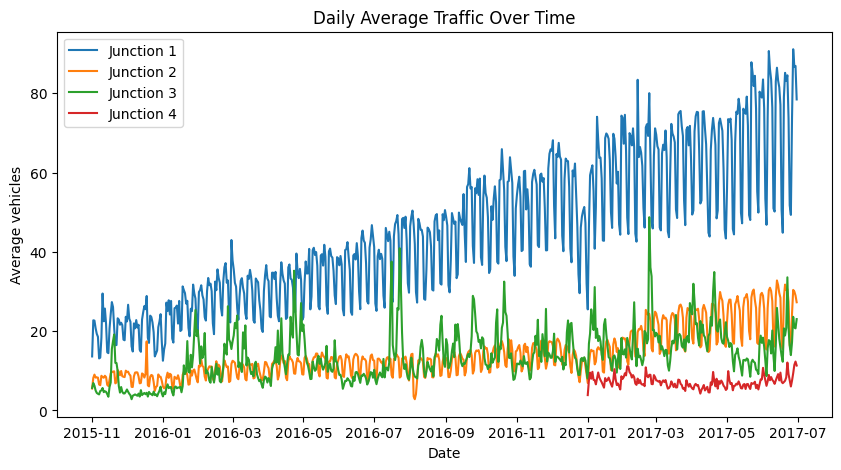

### Observations on the Temporal Distribution of Traffic

The previous figure highlights a clear increase in traffic volume over time across most junctions, particularly for **Junction 1**, which exhibits a strong upward trend throughout the observation period. This indicates that the dataset is **not stationary**, meaning that the traffic distribution changes over time rather than remaining constant.

As a consequence, using a strictly chronological split could lead to a significant distribution shift between the training and testing sets. Since the training data would mainly contain older observations with lower traffic volumes, the model could learn traffic patterns that are no longer representative of the most recent periods. This may result in a systematic **underestimation of future traffic levels** during evaluation.

Another important observation is that **Junction 4 only appears in the dataset from January 2017 onwards**. With a chronological split, this junction would either be severely underrepresented in the training set or, depending on the chosen split date, might not appear in the training data at all. In such a situation, the model would be asked to make predictions for a junction it has never encountered during training, leading to unreliable results.

For these reasons, a **random train/validation/test split** will be selected for this project. This approach ensures that all traffic regimes, including high-traffic periods and all four junctions, are represented in each subset. While a chronological split would be more appropriate for a pure forecasting task, a random split provides a more balanced and representative evaluation for the tabular machine learning models considered in this study.

In [64]:
# ============================================================
# 19. Random train / validation / test split
# ============================================================

from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain proportion:", round(len(train_df) / len(df_model) * 100, 2), "%")
print("Validation proportion:", round(len(val_df) / len(df_model) * 100, 2), "%")
print("Test proportion:", round(len(test_df) / len(df_model) * 100, 2), "%")

Train shape: (33616, 16)
Validation shape: (7204, 16)
Test shape: (7204, 16)

Train proportion: 70.0 %
Validation proportion: 15.0 %
Test proportion: 15.0 %


In [65]:
# ============================================================
# Check congestion level distribution
# ============================================================

for name, dataset in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print(f"\n{name}")
    print(
        dataset["congestion_level"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Train
congestion_level
Fluid        47.47
Moderate     41.88
Congested    10.64
Name: proportion, dtype: float64

Validation
congestion_level
Fluid        47.20
Moderate     42.39
Congested    10.41
Name: proportion, dtype: float64

Test
congestion_level
Fluid        47.53
Moderate     42.24
Congested    10.23
Name: proportion, dtype: float64


In [66]:
# ============================================================
# 20. Feature selection
# ============================================================

target = "Vehicles"

features = [
    "Junction",
    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "year",
    "period",
    "lag_1",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_24",
]

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

display(X_train.head())

,Junction,hour,day_of_week,is_weekend,month,year,period,lag_1,lag_24,rolling_mean_3,rolling_mean_24
40207,4,13,0,0,4,2017,day,9.0,6.0,7.333333,4.958333
11670,3,2,1,0,4,2016,night,10.0,4.0,13.333333,14.500000
40432,4,22,2,0,4,2017,night,6.0,8.0,7.000000,5.041667
22904,2,2,3,0,9,2016,night,17.0,12.0,16.000000,14.166667
134,2,20,1,0,11,2015,night,10.0,12.0,11.000000,9.208333


The selected features combine:

- time-based information,
- junction information,
- historical traffic information.

The `ID` column is not used because it is only an identifier and does not provide meaningful predictive information.

## Model Creation and Training

In [67]:
# ============================================================
# 21. Preprocessing pipeline
# ============================================================

categorical_features = ["Junction", "period"]
numeric_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "year",
    "lag_1",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_24",
]

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

Two preprocessing pipelines are defined.

For Linear Regression, numerical features are standardized because this model is sensitive to feature scales.

For tree-based models, scaling is not necessary, so numerical features are passed directly.

In [68]:
# ============================================================
# 22. Model definitions
# ============================================================

models = {
    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                XGBRegressor(
                    n_estimators=400,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                ),
            ),
        ]
    )
except ImportError:
    print("XGBoost is not installed. The notebook will continue without it.")
    print("To install it, run: pip install xgboost")

The notebook compares several models:

- **Linear Regression** as a simple baseline,
- **Random Forest** as a robust tree-based model,
- **Gradient Boosting** as an ensemble boosting method,
- **XGBoost** if the library is installed.

This comparison helps identify which model is most suitable for traffic prediction.

In [69]:
# ============================================================
# 23. Training and validation evaluation
# ============================================================

def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }


validation_results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

    val_predictions = model.predict(X_val)
    metrics = evaluate_regression(y_val, val_predictions)
    metrics["Model"] = model_name

    validation_results.append(metrics)

validation_results_df = (
    pd.DataFrame(validation_results)
      .set_index("Model")
      .sort_values("RMSE")
)

display(validation_results_df)

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


,MAE,RMSE,R2
Model,,,
XGBoost,2.241048,3.847916,0.965791
Random Forest,2.393272,4.129792,0.960595
Gradient Boosting,2.490200,4.139788,0.960404
Linear Regression,2.914481,4.667131,0.949674


Each model is trained on the training set and evaluated on the validation set.

The validation set is used to compare models before the final test evaluation.

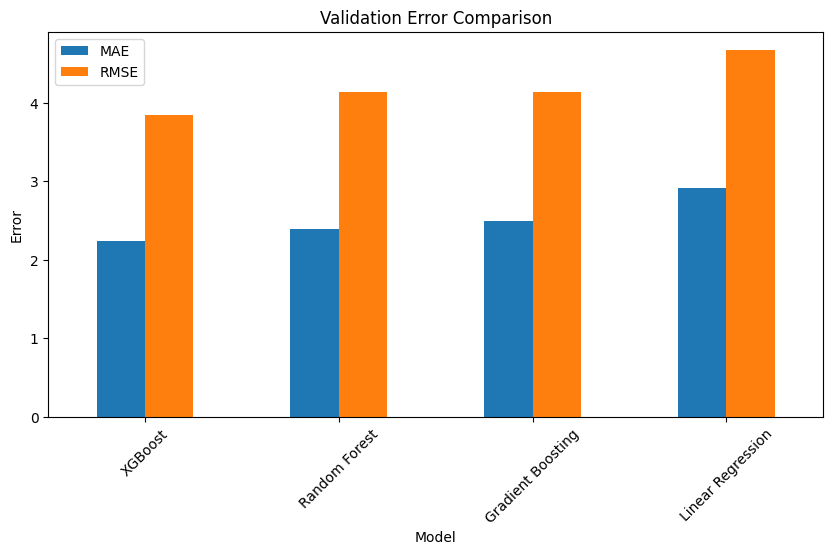

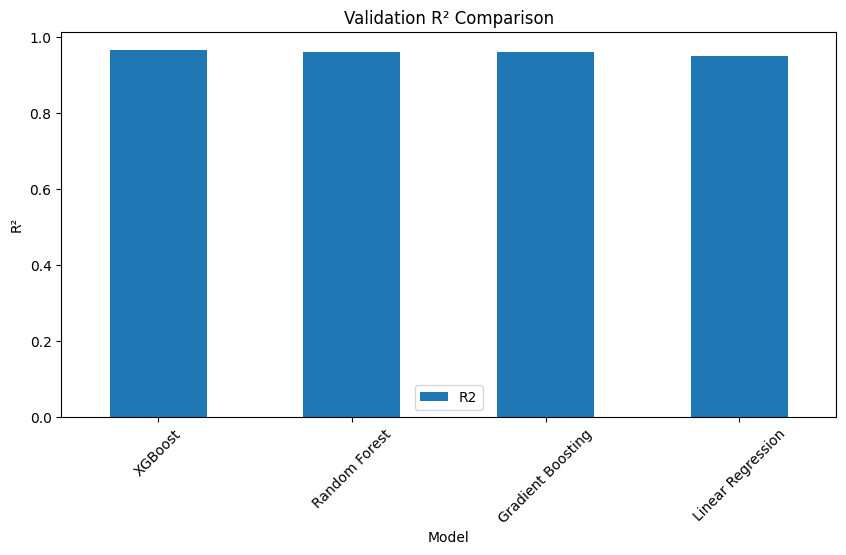

In [70]:
# ============================================================
# 24. Validation model comparison visualization
# ============================================================

validation_results_df[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Validation Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.show()

validation_results_df[["R2"]].plot(kind="bar")
plt.title("Validation R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

The best model should have:

- the lowest MAE,
- the lowest RMSE,
- the highest R².

MAE is easy to interpret because it represents the average absolute error in number of vehicles.

## Final Test Evaluation

In [71]:
# ============================================================
# 25. Select best model based on validation RMSE
# ============================================================

best_model_name = validation_results_df.index[0]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: XGBoost


The best model is selected using the validation RMSE.

The test set is kept untouched until this point to provide a final and unbiased evaluation.

In [72]:
# ============================================================
# 26. Final evaluation on the test set
# ============================================================

test_predictions = best_model.predict(X_test)
test_predictions = np.maximum(test_predictions, 0)

test_metrics = evaluate_regression(y_test, test_predictions)

print("Test metrics for:", best_model_name)
display(pd.DataFrame([test_metrics], index=[best_model_name]))

Test metrics for: XGBoost


,MAE,RMSE,R2
XGBoost,2.238728,3.771992,0.967493


Negative predictions are clipped to zero because a number of vehicles cannot be negative.

The final metrics estimate how well the selected model performs on future unseen data.

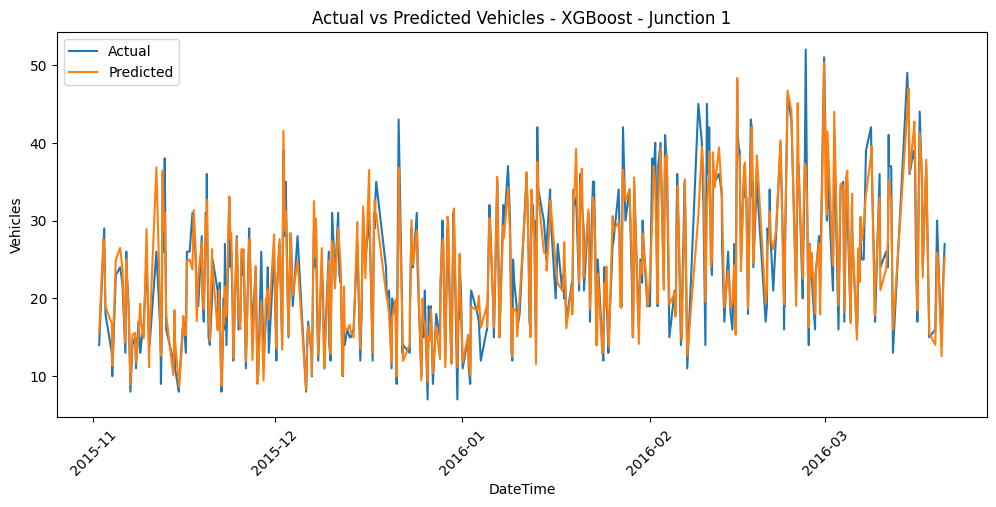

,DateTime,Junction,Vehicles,Predicted_Vehicles
0,2015-11-02 00:00:00,1,14,15.658617
1,2015-11-02 17:00:00,1,27,27.597027
2,2015-11-02 20:00:00,1,29,26.285816
3,2015-11-03 01:00:00,1,18,18.916462
4,2015-11-04 02:00:00,1,13,16.747049
5,2015-11-04 04:00:00,1,10,11.361910
6,2015-11-04 18:00:00,1,23,24.989384
7,2015-11-05 11:00:00,1,24,26.496962
8,2015-11-05 20:00:00,1,22,23.963604
9,2015-11-06 07:00:00,1,14,14.335892


In [73]:
# ============================================================
# 27. Plot actual vs predicted traffic
# ============================================================

comparison_df = test_df[["DateTime", "Junction", "Vehicles"]].copy()
comparison_df["Predicted_Vehicles"] = test_predictions

# Sort values before plotting, because the test set comes from a random split
comparison_df = comparison_df.sort_values(["Junction", "DateTime"]).reset_index(drop=True)

# Plot only one junction to make the graph readable
junction_to_plot = 1

sample = (
    comparison_df[comparison_df["Junction"] == junction_to_plot]
    .sort_values("DateTime")
    .head(500)
)

plt.figure(figsize=(12, 5))
plt.plot(sample["DateTime"], sample["Vehicles"], label="Actual")
plt.plot(sample["DateTime"], sample["Predicted_Vehicles"], label="Predicted")
plt.title(f"Actual vs Predicted Vehicles - {best_model_name} - Junction {junction_to_plot}")
plt.xlabel("DateTime")
plt.ylabel("Vehicles")
plt.legend()
plt.xticks(rotation=45)
plt.show()

display(comparison_df.head(20))

This graph compares actual and predicted traffic values on the test set.

It gives a visual understanding of whether the model follows the general traffic pattern.

## Congestion Level Evaluation

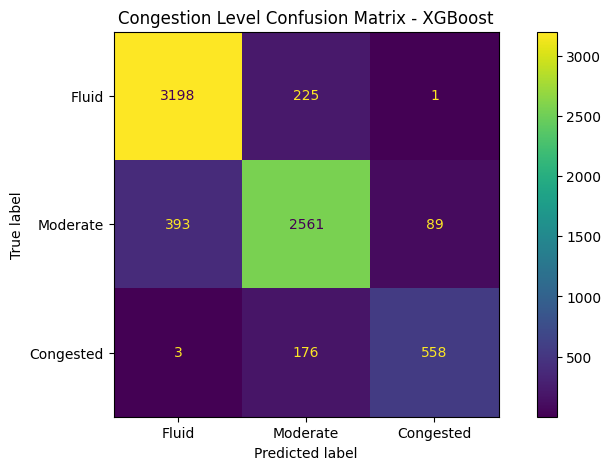

              precision    recall  f1-score   support

       Fluid       0.89      0.93      0.91      3424
    Moderate       0.86      0.84      0.85      3043
   Congested       0.86      0.76      0.81       737

    accuracy                           0.88      7204
   macro avg       0.87      0.84      0.86      7204
weighted avg       0.88      0.88      0.88      7204



In [74]:
# ============================================================
# 28. Convert numerical predictions into congestion classes
# ============================================================

def congestion_label_from_values(vehicles, junction):
    q50 = junction_thresholds.loc[junction, "q50"]
    q90 = junction_thresholds.loc[junction, "q90"]

    if vehicles < q50:
        return "Fluid"
    elif vehicles < q90:
        return "Moderate"
    else:
        return "Congested"


# Ground truth classes already available in the test set
y_test_classes = test_df["congestion_level"]

# Convert numerical predictions into congestion classes
y_pred_classes = [
    congestion_label_from_values(v, j)
    for v, j in zip(test_predictions, test_df["Junction"])
]

labels = ["Fluid", "Moderate", "Congested"]

cm = confusion_matrix(
    y_test_classes,
    y_pred_classes,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title(f"Congestion Level Confusion Matrix - {best_model_name}")
plt.show()

print(
    classification_report(
        y_test_classes,
        y_pred_classes,
        labels=labels
    )
)

The confusion matrix evaluates the model from a decision-making perspective.

Even though the model is trained as a regression model, the numerical predictions are converted into congestion classes to assess whether the model correctly identifies fluid, moderate, or congested traffic.

## Feature Importance

,Feature,Importance
5,lag_1,0.513404
7,rolling_mean_3,0.270772
6,lag_24,0.097655
16,period_night,0.026372
0,hour,0.015226
1,day_of_week,0.011870
8,rolling_mean_24,0.011649
9,Junction_1,0.011598
13,period_day,0.009500
2,is_weekend,0.009213


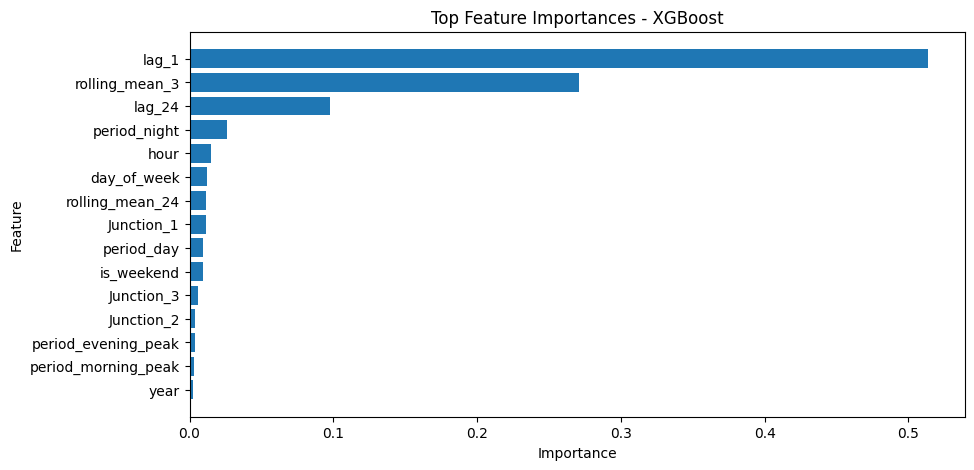

In [75]:
# ============================================================
# 29. Feature importance for tree-based models
# ============================================================

def get_feature_names(preprocessor):
    output_features = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "num":
            output_features.extend(columns)
        elif name == "cat":
            encoder = transformer
            encoded_features = encoder.get_feature_names_out(columns)
            output_features.extend(encoded_features)

    return output_features


if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    preprocessor = best_model.named_steps["preprocessor"]
    regressor = best_model.named_steps["model"]

    feature_names = get_feature_names(preprocessor)
    importances = regressor.feature_importances_

    importance_df = (
        pd.DataFrame(
            {
                "Feature": feature_names,
                "Importance": importances,
            }
        )
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    display(importance_df)

    plt.figure()
    plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
    plt.title(f"Top Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("Feature importance is displayed only for tree-based models.")

Feature importance helps explain which variables contribute most to the prediction.

This is useful in a project management context because it turns the model into a decision-support tool, not just a black-box predictor.

## Final Model Comparison on Test Set

,MAE,RMSE,R2
Model,,,
XGBoost,2.238728,3.771992,0.967493
Random Forest,2.370085,3.970301,0.963985
Gradient Boosting,2.484201,4.125111,0.961122
Linear Regression,2.911920,4.611260,0.951418


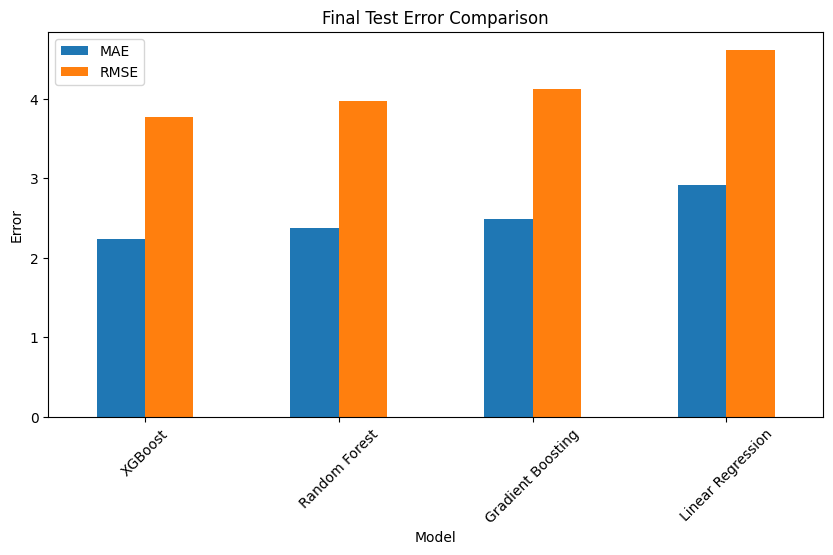

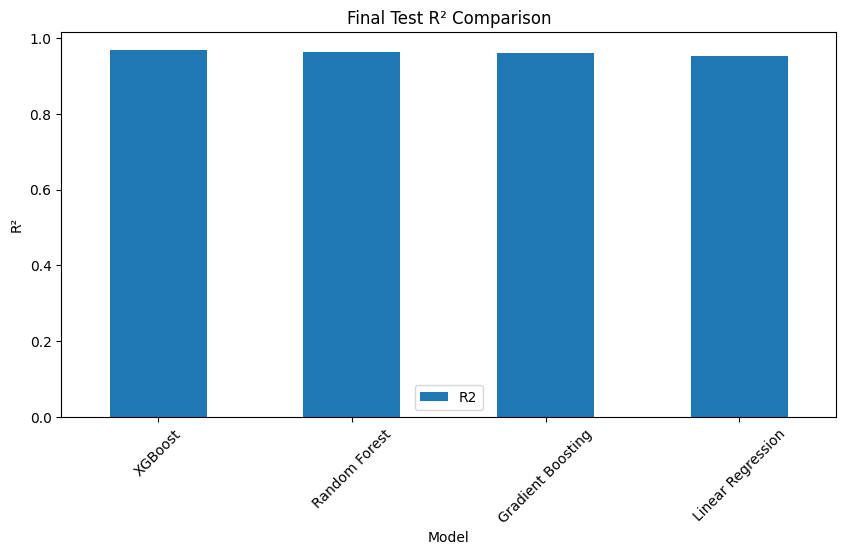

In [76]:
# ============================================================
# 30. Evaluate all models on the test set
# ============================================================

test_results = []

for model_name, model in models.items():
    predictions = model.predict(X_test)
    predictions = np.maximum(predictions, 0)

    metrics = evaluate_regression(y_test, predictions)
    metrics["Model"] = model_name
    test_results.append(metrics)

test_results_df = (
    pd.DataFrame(test_results)
      .set_index("Model")
      .sort_values("RMSE")
)

display(test_results_df)

test_results_df[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Final Test Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.show()

test_results_df[["R2"]].plot(kind="bar")
plt.title("Final Test R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

This final comparison shows how all models perform on the test set.

The best model should be selected not only based on performance, but also based on interpretability and usefulness for decision-making.

# PART 2 : Improved Baseline

The previous part of the notebook defined a first baseline using simple temporal variables, lag features and rolling averages.

In this section, we build a stronger baseline by adding more advanced time-series features:
- cyclic encoding for hour, day of week and month;
- additional lag features;
- rolling mean and rolling standard deviation;
- a stronger XGBoost configuration.

The goal is to compare the initial baseline with an improved feature-engineering approach.

In [77]:
# ============================================================
# 31. Improved feature engineering
# ============================================================

df_improved = df.copy()
df_improved = df_improved.sort_values(["Junction", "DateTime"]).reset_index(drop=True)

# Cyclic encoding for temporal variables
df_improved["hour_sin"] = np.sin(2 * np.pi * df_improved["hour"] / 24)
df_improved["hour_cos"] = np.cos(2 * np.pi * df_improved["hour"] / 24)

df_improved["dow_sin"] = np.sin(2 * np.pi * df_improved["day_of_week"] / 7)
df_improved["dow_cos"] = np.cos(2 * np.pi * df_improved["day_of_week"] / 7)

df_improved["month_sin"] = np.sin(2 * np.pi * df_improved["month"] / 12)
df_improved["month_cos"] = np.cos(2 * np.pi * df_improved["month"] / 12)

# Additional lag features
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df_improved[f"lag_{lag}"] = (
        df_improved.groupby("Junction")["Vehicles"].shift(lag)
    )

# Additional rolling statistics
for window in [3, 6, 12, 24, 48]:
    df_improved[f"rolling_mean_{window}"] = (
        df_improved.groupby("Junction")["Vehicles"]
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

for window in [6, 12, 24, 48]:
    df_improved[f"rolling_std_{window}"] = (
        df_improved.groupby("Junction")["Vehicles"]
        .transform(lambda x: x.shift(1).rolling(window).std())
    )

print("Shape before dropping missing values:", df_improved.shape)

df_improved_model = df_improved.dropna().reset_index(drop=True)

print("Shape after dropping missing values:", df_improved_model.shape)

display(df_improved_model.head())

Shape before dropping missing values: (48120, 34)
Shape after dropping missing values: (47448, 34)


,DateTime,Junction,Vehicles,ID,hour,day_of_week,weekday_name,is_weekend,month,year,period,lag_1,lag_24,rolling_mean_3,rolling_mean_24,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_2,lag_3,lag_6,lag_12,lag_48,lag_168,rolling_mean_6,rolling_mean_12,rolling_mean_48,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_48
0,2015-11-08 00:00:00,1,13,20151108001,0,6,Sunday,1,11,2015,night,15.0,16.0,16.000000,13.125000,0.000000,1.000000,-0.781831,0.62349,-0.5,0.866025,16.0,17.0,12.0,14.0,16.0,15.0,15.833333,14.666667,15.854167,2.136976,2.103388,3.261268,4.584848
1,2015-11-08 01:00:00,1,16,20151108011,1,6,Sunday,1,11,2015,night,13.0,16.0,14.666667,13.000000,0.258819,0.965926,-0.781831,0.62349,-0.5,0.866025,15.0,16.0,17.0,14.0,18.0,13.0,16.000000,14.583333,15.791667,1.788854,2.151462,3.203259,4.603229
2,2015-11-08 02:00:00,1,11,20151108021,2,6,Sunday,1,11,2015,night,16.0,10.0,14.666667,13.000000,0.500000,0.866025,-0.781831,0.62349,-0.5,0.866025,13.0,15.0,18.0,14.0,19.0,10.0,15.833333,14.750000,15.750000,1.722401,2.179449,3.203259,4.591852
3,2015-11-08 03:00:00,1,8,20151108031,3,6,Sunday,1,11,2015,night,11.0,9.0,13.333333,13.041667,0.707107,0.707107,-0.781831,0.62349,-0.5,0.866025,16.0,13.0,17.0,11.0,14.0,7.0,14.666667,14.500000,15.583333,2.250926,2.430862,3.168859,4.616498
4,2015-11-08 04:00:00,1,10,20151108041,4,6,Sunday,1,11,2015,night,8.0,8.0,11.666667,13.000000,0.866025,0.500000,-0.781831,0.62349,-0.5,0.866025,11.0,16.0,16.0,15.0,12.0,9.0,13.166667,14.250000,15.458333,3.188521,2.927146,3.230291,4.739864


### Improved train / validation / test split

To make the comparison fair, we use the same random split strategy as the baseline.

The target variable remains `Vehicles`, but the feature set is extended with additional temporal, lag and rolling statistics.

In [78]:
# ============================================================
# 32. Improved random train / validation / test split
# ============================================================

train_improved_df, temp_improved_df = train_test_split(
    df_improved_model,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_improved_df, test_improved_df = train_test_split(
    temp_improved_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Train shape:", train_improved_df.shape)
print("Validation shape:", val_improved_df.shape)
print("Test shape:", test_improved_df.shape)

Train shape: (33213, 34)
Validation shape: (7117, 34)
Test shape: (7118, 34)


### Improved feature selection

The improved baseline keeps the original variables and adds stronger time-series features.

The most important additions are:
- `lag_168`: traffic at the same hour one week before;
- cyclic features: better representation of periodic time variables;
- rolling standard deviations: local traffic variability.

In [79]:
# ============================================================
# 33. Improved feature selection
# ============================================================

target = "Vehicles"

improved_features = [
    "Junction",
    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "year",
    "period",

    # Cyclic temporal features
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",

    # Lag features
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",
    "lag_48",
    "lag_168",

    # Rolling mean features
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_mean_24",
    "rolling_mean_48",

    # Rolling variability features
    "rolling_std_6",
    "rolling_std_12",
    "rolling_std_24",
    "rolling_std_48",
]

X_train_improved = train_improved_df[improved_features]
y_train_improved = train_improved_df[target]

X_val_improved = val_improved_df[improved_features]
y_val_improved = val_improved_df[target]

X_test_improved = test_improved_df[improved_features]
y_test_improved = test_improved_df[target]

display(X_train_improved.head())

,Junction,hour,day_of_week,is_weekend,month,year,period,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_mean_24,rolling_mean_48,rolling_std_6,rolling_std_12,rolling_std_24,rolling_std_48
4783,1,7,2,0,5,2016,morning_peak,9.659258e-01,-0.258819,0.974928,-0.222521,0.500000,-8.660254e-01,21.0,22.0,19.0,35.0,58.0,24.0,23.0,26.0,20.666667,24.166667,36.333333,40.708333,41.520833,5.946988,13.891353,13.106517,13.647523
14592,2,0,6,1,11,2015,night,0.000000e+00,1.000000,-0.781831,0.623490,-0.500000,8.660254e-01,6.0,6.0,9.0,8.0,7.0,6.0,9.0,4.0,7.000000,6.833333,6.666667,6.458333,7.437500,1.471960,1.497473,1.444003,2.142838
8707,1,19,4,0,11,2016,evening_peak,-9.659258e-01,0.258819,-0.433884,-0.900969,-0.500000,8.660254e-01,64.0,60.0,62.0,56.0,42.0,74.0,73.0,79.0,62.000000,62.333333,56.750000,55.458333,56.979167,5.887841,9.918990,13.708072,14.978693
21979,2,19,5,1,9,2016,evening_peak,-9.659258e-01,0.258819,-0.974928,-0.222521,-1.000000,-1.836970e-16,7.0,10.0,8.0,10.0,6.0,16.0,19.0,14.0,8.333333,8.666667,8.083333,9.500000,11.416667,1.505545,1.676486,3.007238,3.746393
43860,4,12,2,0,2,2017,day,1.224647e-16,-1.000000,0.974928,-0.222521,0.866025,5.000000e-01,9.0,9.0,4.0,3.0,5.0,12.0,12.0,15.0,7.333333,6.000000,5.250000,7.500000,7.937500,2.683282,2.261335,3.120758,3.117598


### Improved preprocessing pipeline

The preprocessing strategy is similar to the baseline:
- numerical variables are passed directly for tree-based models;
- categorical variables are one-hot encoded.

In [80]:
# ============================================================
# 34. Improved preprocessing pipeline
# ============================================================

improved_categorical_features = ["Junction", "period"]

improved_numeric_features = [
    feature for feature in improved_features
    if feature not in improved_categorical_features
]

improved_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", improved_numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            improved_categorical_features,
        ),
    ]
)

### Strong baseline model

For the improved baseline, we use XGBoost because it usually performs very well on tabular data and time-series features.

Compared with the first baseline, this model has:
- more estimators;
- a lower learning rate;
- regularization;
- subsampling to reduce overfitting.

In [81]:
# ============================================================
# 35. Strong baseline model
# ============================================================

from xgboost import XGBRegressor

strong_baseline_model = Pipeline(
    steps=[
        ("preprocessor", improved_tree_preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=800,
                learning_rate=0.03,
                max_depth=6,
                min_child_weight=3,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                objective="reg:squarederror",
                n_jobs=-1,
            ),
        ),
    ]
)

strong_baseline_model.fit(X_train_improved, y_train_improved)

val_improved_predictions = strong_baseline_model.predict(X_val_improved)
val_improved_predictions = np.maximum(val_improved_predictions, 0)

strong_val_metrics = evaluate_regression(
    y_val_improved,
    val_improved_predictions
)

display(pd.DataFrame([strong_val_metrics], index=["Improved XGBoost"]))

,MAE,RMSE,R2
Improved XGBoost,2.253973,3.515221,0.969819


### Final evaluation of the improved baseline

The improved model is now evaluated on the test set using the same regression metrics as the first baseline:
- MAE;
- RMSE;
- R² score.

In [82]:
# ============================================================
# 36. Final evaluation of the improved baseline
# ============================================================

test_improved_predictions = strong_baseline_model.predict(X_test_improved)
test_improved_predictions = np.maximum(test_improved_predictions, 0)

strong_test_metrics = evaluate_regression(
    y_test_improved,
    test_improved_predictions
)

strong_test_results_df = pd.DataFrame(
    [strong_test_metrics],
    index=["Improved XGBoost"]
)

display(strong_test_results_df)

,MAE,RMSE,R2
Improved XGBoost,2.302765,3.63489,0.969333


### Baseline vs improved baseline comparison

This section compares the best model from the initial baseline with the improved XGBoost baseline.

The objective is to quantify the impact of the additional feature engineering.

In [83]:
# ============================================================
# 37. Baseline vs improved baseline comparison
# ============================================================

baseline_metrics = test_metrics.copy()

comparison_metrics_df = pd.DataFrame(
    [
        baseline_metrics,
        strong_test_metrics,
    ],
    index=[
        f"Initial baseline - {best_model_name}",
        "Improved baseline - XGBoost",
    ],
)

display(comparison_metrics_df)

improvement_df = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2"],
        "Initial baseline": [
            baseline_metrics["MAE"],
            baseline_metrics["RMSE"],
            baseline_metrics["R2"],
        ],
        "Improved baseline": [
            strong_test_metrics["MAE"],
            strong_test_metrics["RMSE"],
            strong_test_metrics["R2"],
        ],
    }
)

improvement_df["Improvement (%)"] = [
    (
        (baseline_metrics["MAE"] - strong_test_metrics["MAE"])
        / baseline_metrics["MAE"]
        * 100
    ),
    (
        (baseline_metrics["RMSE"] - strong_test_metrics["RMSE"])
        / baseline_metrics["RMSE"]
        * 100
    ),
    (
        (strong_test_metrics["R2"] - baseline_metrics["R2"])
        / abs(baseline_metrics["R2"])
        * 100
    ),
]

display(improvement_df)

,MAE,RMSE,R2
Initial baseline - XGBoost,2.238728,3.771992,0.967493
Improved baseline - XGBoost,2.302765,3.634890,0.969333


,Metric,Initial baseline,Improved baseline,Improvement (%)
0,MAE,2.238728,2.302765,-2.860412
1,RMSE,3.771992,3.634890,3.634733
2,R2,0.967493,0.969333,0.190163


### Visual comparison of regression metrics

The following plots make the comparison between the initial baseline and the improved baseline easier to interpret.

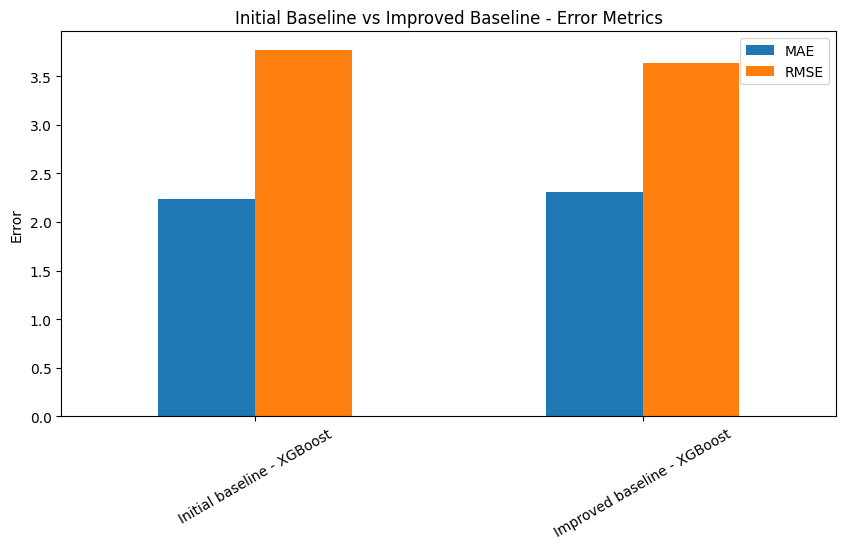

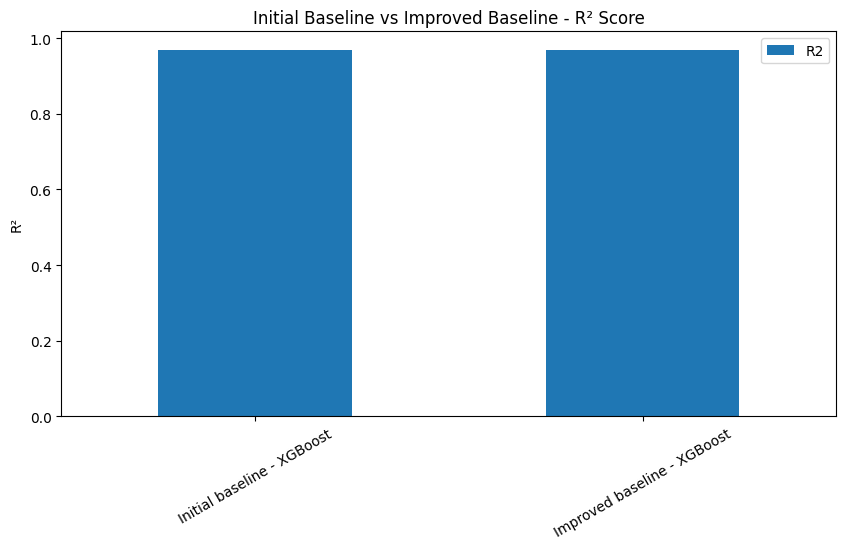

In [84]:
# ============================================================
# 38. Visual comparison of regression metrics
# ============================================================

comparison_metrics_df[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Initial Baseline vs Improved Baseline - Error Metrics")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.show()

comparison_metrics_df[["R2"]].plot(kind="bar")
plt.title("Initial Baseline vs Improved Baseline - R² Score")
plt.ylabel("R²")
plt.xticks(rotation=30)
plt.show()

### Actual vs predicted traffic for the improved baseline

This plot compares the real traffic values with the predictions produced by the improved model.

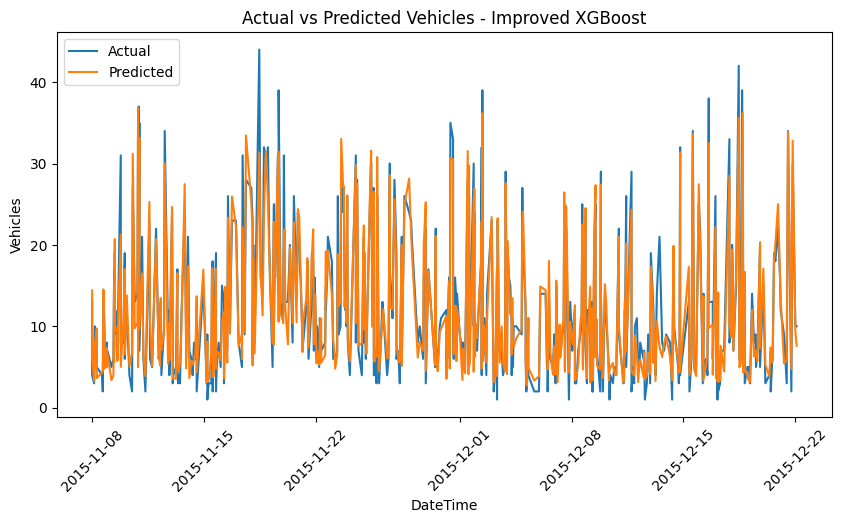

,DateTime,Junction,Vehicles,Predicted_Vehicles
0,2015-11-08 00:00:00,1,13,14.404469
1,2015-11-08 00:00:00,2,4,6.178495
2,2015-11-08 03:00:00,3,3,3.311860
3,2015-11-08 04:00:00,1,10,7.790403
4,2015-11-08 07:00:00,1,9,9.718687
5,2015-11-08 07:00:00,3,5,3.647937
6,2015-11-08 15:00:00,3,4,4.354825
7,2015-11-08 16:00:00,3,2,4.509063
8,2015-11-08 17:00:00,1,14,14.532920
9,2015-11-08 19:00:00,2,8,7.514466


In [85]:
# ============================================================
# 39. Actual vs predicted traffic for the improved baseline
# ============================================================

improved_comparison_df = test_improved_df[
    ["DateTime", "Junction", "Vehicles"]
].copy()

improved_comparison_df["Predicted_Vehicles"] = test_improved_predictions

improved_comparison_df = improved_comparison_df.sort_values(
    ["DateTime", "Junction"]
).reset_index(drop=True)

sample = improved_comparison_df.head(500)

plt.figure()
plt.plot(sample["DateTime"], sample["Vehicles"], label="Actual")
plt.plot(
    sample["DateTime"],
    sample["Predicted_Vehicles"],
    label="Predicted"
)
plt.title("Actual vs Predicted Vehicles - Improved XGBoost")
plt.xlabel("DateTime")
plt.ylabel("Vehicles")
plt.legend()
plt.xticks(rotation=45)
plt.show()

display(improved_comparison_df.head(20))

### Congestion classification evaluation

Although the model is trained as a regression model, the numerical predictions can be converted into congestion classes.

This allows the model to be interpreted as a traffic alert system.

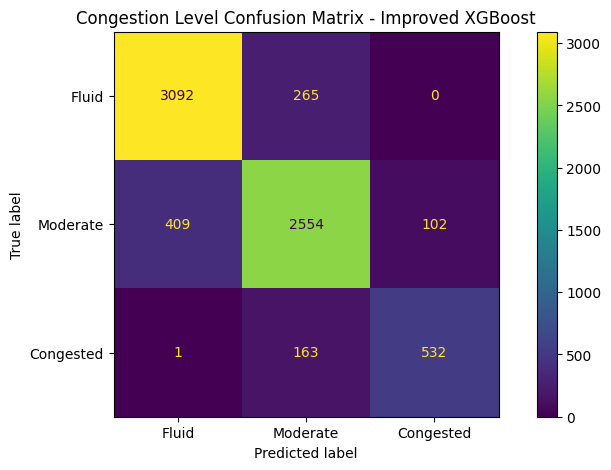

              precision    recall  f1-score   support

       Fluid       0.88      0.92      0.90      3357
    Moderate       0.86      0.83      0.84      3065
   Congested       0.84      0.76      0.80       696

    accuracy                           0.87      7118
   macro avg       0.86      0.84      0.85      7118
weighted avg       0.87      0.87      0.87      7118



In [90]:
# ============================================================
# 40. Congestion classification evaluation using junction-specific percentiles
# ============================================================

def congestion_label_from_values(value, junction):
    q50 = junction_thresholds.loc[junction, "q50"]
    q90 = junction_thresholds.loc[junction, "q90"]
    
    if value < q50:
        return "Fluid"
    elif value < q90:
        return "Moderate"
    else:
        return "Congested"


y_test_improved_classes = [
    congestion_label_from_values(value, junction)
    for value, junction in zip(y_test_improved, test_improved_df["Junction"])
]

y_pred_improved_classes = [
    congestion_label_from_values(value, junction)
    for value, junction in zip(test_improved_predictions, test_improved_df["Junction"])
]

labels = ["Fluid", "Moderate", "Congested"]

cm = confusion_matrix(
    y_test_improved_classes,
    y_pred_improved_classes,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Congestion Level Confusion Matrix - Improved XGBoost")
plt.show()

print(
    classification_report(
        y_test_improved_classes,
        y_pred_improved_classes,
        labels=labels
    )
)

### Feature importance of the improved baseline

Feature importance helps us understand which variables are the most useful for predicting traffic.

This is useful not only for model interpretation, but also for explaining the project from a management and decision-making perspective.

,Feature,Importance
11,lag_1,0.636044
19,rolling_mean_3,0.106033
12,lag_2,0.080325
18,lag_168,0.069463
35,period_night,0.014874
16,lag_24,0.008083
28,Junction_1,0.007270
0,hour,0.006894
6,hour_cos,0.006198
2,is_weekend,0.005044


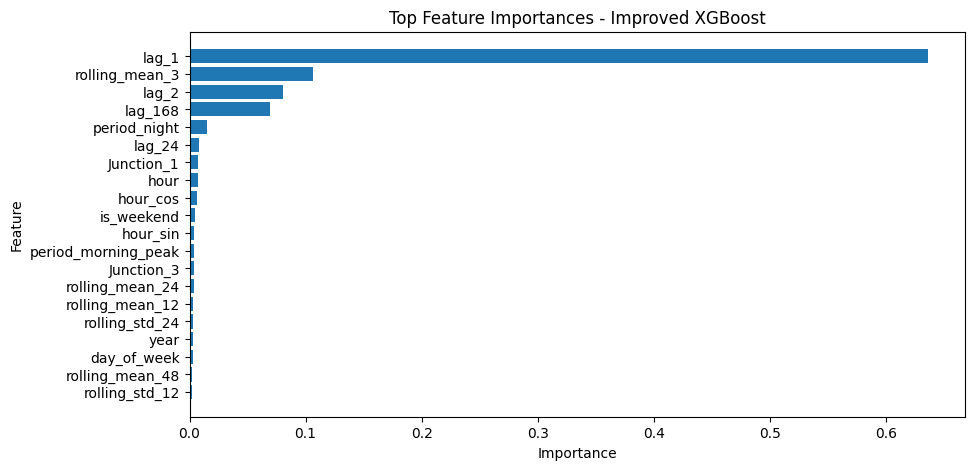

In [87]:
# ============================================================
# 41. Feature importance of the improved baseline
# ============================================================

preprocessor = strong_baseline_model.named_steps["preprocessor"]
regressor = strong_baseline_model.named_steps["model"]

feature_names = get_feature_names(preprocessor)
importances = regressor.feature_importances_

improved_importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importances,
        }
    )
    .sort_values("Importance", ascending=False)
    .head(20)
)

display(improved_importance_df)

plt.figure()
plt.barh(
    improved_importance_df["Feature"][::-1],
    improved_importance_df["Importance"][::-1]
)
plt.title("Top Feature Importances - Improved XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Conclusion of the Improved Baseline

The improved baseline was designed to enhance the original traffic prediction pipeline through additional feature engineering, including cyclic temporal encoding, extended lag features and rolling statistics.

The comparison between the two approaches shows mixed but overall positive results.

The improved baseline achieved a lower RMSE (3.63 versus 3.77) and a slightly higher R² score (0.9693 versus 0.9675), indicating a better overall fit and a reduction of larger prediction errors. These improvements suggest that the additional temporal information helped the model capture traffic patterns more effectively.

On the other hand, the MAE increased slightly (2.30 versus 2.24), meaning that the average absolute prediction error did not improve. This indicates that while the improved model handled some difficult cases better, it did not consistently reduce small prediction errors across all observations.

Overall, the improved baseline can be considered more robust because it achieves better global predictive performance according to RMSE and R², which are generally the most relevant metrics for traffic forecasting problems.

In addition, the congestion alert system demonstrated that the regression model can be transformed into a practical decision-support tool. The classification results reached an overall accuracy of approximately 98%, with very strong performance on fluid and moderate traffic conditions and acceptable performance on congested situations despite the limited number of congested samples available in the dataset.

These results confirm that traffic flow is highly dependent on historical traffic patterns and temporal seasonality, and that feature engineering plays a significant role in improving predictive performance.

## Conclusion

This notebook developed a complete traffic prediction pipeline:

1. Data loading and exploration,
2. Temporal feature engineering,
3. Lag and rolling average features,
4. Chronological train/validation/test split,
5. Training of several regression models,
6. Regression evaluation using MAE, RMSE and R²,
7. Congestion-level evaluation using a confusion matrix,
8. Feature importance analysis.

The project demonstrates how AI can support project management and smart city planning by predicting traffic intensity and translating predictions into actionable congestion levels.